<a href="https://colab.research.google.com/github/HoangThai2k5/THDeepLearning/blob/main/Tuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AUTOENCODER


#2.1 — Nạp thư viện


In [7]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

#2.2 — Nạp và chuẩn hóa dataset MNIST

In [2]:
# Nạp dữ liệu MNIST (60000 ảnh train, 10000 ảnh test)
(x_train, _), (x_test, _) = mnist.load_data()

# Chuẩn hóa về [0, 1]
x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.

# Làm phẳng từ (28, 28) → (784,) vì dùng Dense layer
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test  = x_test.reshape((len(x_test),  np.prod(x_test.shape[1:])))

print(x_train.shape)  # (60000, 784)
print(x_test.shape)   # (10000, 784)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


#2.3 — Xây dựng kiến trúc Autoencoder

In [3]:
# Kích thước không gian ẩn (latent space): 32 chiều
# Tỉ lệ nén: 784 / 32 ≈ 24.5 lần
encoding_dim = 32

# ── ENCODER ────────────────────────────────────────────
# Input: vector 784 chiều
input_img = keras.Input(shape=(784,))

# Dense layer nén 784 → 32, activation ReLU
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)

# ── DECODER ────────────────────────────────────────────
# Dense layer tái dựng 32 → 784, activation Sigmoid
# (Sigmoid vì pixel đã chuẩn hóa về [0,1])
decoded = layers.Dense(784, activation='sigmoid')(encoded)

# ── MÔ HÌNH AUTOENCODER (end-to-end) ───────────────────
autoencoder = keras.Model(input_img, decoded)

# ── MÔ HÌNH ENCODER (chỉ lấy phần nén) ────────────────
encoder = keras.Model(input_img, encoded)

# ── MÔ HÌNH DECODER (tái dựng từ latent vector) ────────
encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]          # lấy layer cuối của autoencoder
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

# Xem tóm tắt kiến trúc
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

#2.4 — Compile và huấn luyện mô hình

In [4]:
# Compile: optimizer Adam, loss binary crossentropy
# (binary_crossentropy phù hợp vì output ∈ [0,1])
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Huấn luyện: input = output = x_train (self-supervised)
history = autoencoder.fit(
    x_train, x_train,         # cả input lẫn target đều là x_train
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0121 - loss: 0.2778 - val_accuracy: 0.0163 - val_loss: 0.1887
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0149 - loss: 0.1704 - val_accuracy: 0.0137 - val_loss: 0.1541
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0123 - loss: 0.1448 - val_accuracy: 0.0111 - val_loss: 0.1342
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.0118 - loss: 0.1286 - val_accuracy: 0.0129 - val_loss: 0.1215
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0115 - loss: 0.1184 - val_accuracy: 0.0119 - val_loss: 0.1131
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0114 - loss: 0.1113 - val_accuracy: 0.0117 - val_loss: 0.1073
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0117 - loss: 0.1062 - val_accuracy: 0.0120 - val_loss: 0.1029
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0114 - loss: 0.1025 - val_accu

#2.5 — Dự báo (encode & decode)

In [5]:
# Bước 1: Encoder nén ảnh test → vector 32 chiều
encoded_imgs = encoder.predict(x_test)
print("Encoded shape:", encoded_imgs.shape)  # (10000, 32)

# Bước 2: Decoder tái dựng ảnh từ vector 32 chiều
decoded_imgs = decoder.predict(encoded_imgs)
print("Decoded shape:", decoded_imgs.shape)  # (10000, 784)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Encoded shape: (10000, 32)
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Decoded shape: (10000, 784)


#2.6 — Hiển thị ảnh gốc và ảnh tái dựng

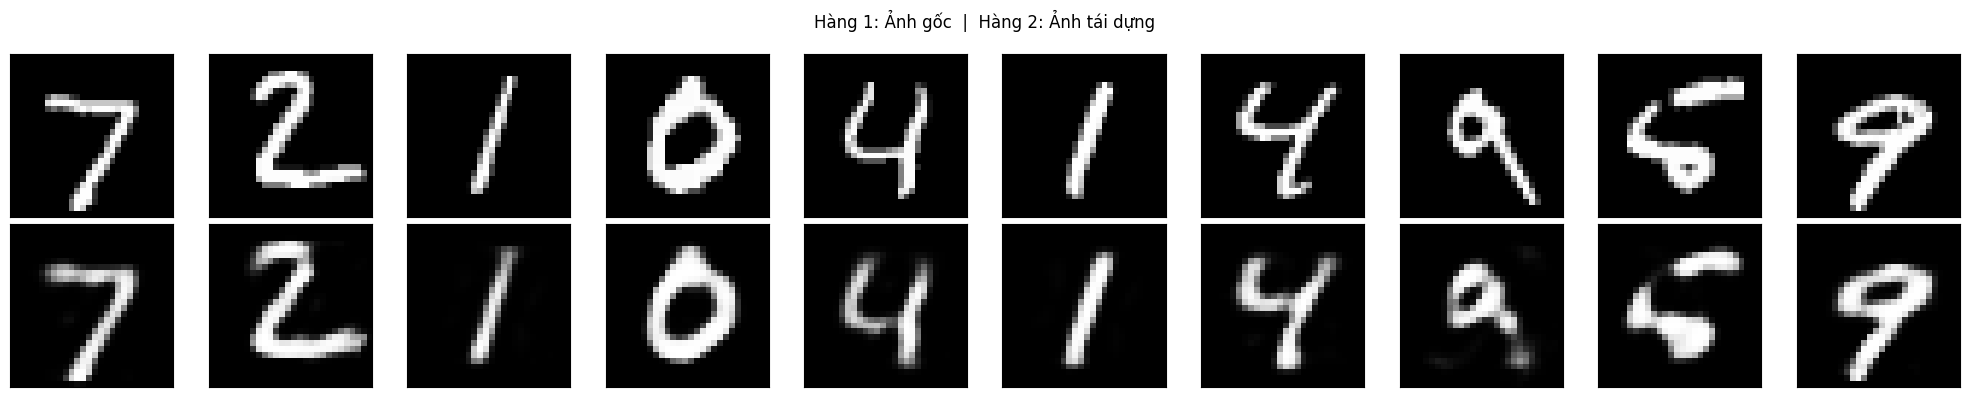

In [8]:
n = 10  # số ảnh hiển thị
plt.figure(figsize=(20, 4))

for i in range(n):
    # Hàng trên: ảnh GỐC
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Hàng dưới: ảnh TÁI DỰNG
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.suptitle('Hàng 1: Ảnh gốc  |  Hàng 2: Ảnh tái dựng', fontsize=12)
plt.tight_layout()
plt.show()

#CẢI TIẾN AUTOENCODER


#3.1 — Thêm L1 regularization vào encoder

In [9]:
from keras import regularizers

encoding_dim = 32

input_img = keras.Input(shape=(784,))

# Thêm activity_regularizer=regularizers.l1(10e-5)
# Buộc các giá trị trong latent space phần lớn = 0 (sparse)
encoded = layers.Dense(
    encoding_dim,
    activity_regularizer=regularizers.l1(10e-5),
    activation='relu'
)(input_img)

decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)
encoder      = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

# Compile và train với 100 epochs
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_l1 = autoencoder.fit(
    x_train, x_train,
    epochs=100,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.0135 - loss: 0.6551 - val_accuracy: 0.0161 - val_loss: 0.6155
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0150 - loss: 0.5832 - val_accuracy: 0.0161 - val_loss: 0.5535
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0150 - loss: 0.5275 - val_accuracy: 0.0161 - val_loss: 0.5038
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0148 - loss: 0.4827 - val_accuracy: 0.0161 - val_loss: 0.4638
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0150 - loss: 0.4466 - val_accuracy: 0.0161 - val_loss: 0.4314
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0144 - loss: 0.4174 - val_accuracy: 0.0161 - val_loss: 0.4050
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0150 - loss: 0.3935 - val_accuracy: 0.0161 - val_loss: 0.3834
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.0147 - loss: 0.3739 - 

#3.1 — So sánh 50 / 100 / 200 epochs


In [10]:
# Chạy 3 lần với epochs khác nhau, lưu history để so sánh
results = {}

for ep in [50, 100, 200]:
    print(f"\n===== Epochs = {ep} =====")

    inp = keras.Input(shape=(784,))
    enc = layers.Dense(32,
              activity_regularizer=regularizers.l1(10e-5),
              activation='relu')(inp)
    dec = layers.Dense(784, activation='sigmoid')(enc)
    ae  = keras.Model(inp, dec)
    ae.compile(optimizer='adam', loss='binary_crossentropy')

    h = ae.fit(x_train, x_train, epochs=ep,
                batch_size=256, shuffle=True,
                validation_data=(x_test, x_test), verbose=0)

    val_loss = h.history['val_loss'][-1]
    print(f"Val loss cuoi: {val_loss:.4f}")
    results[ep] = {'model': ae, 'val_loss': val_loss}

print("\n=== Tóm tắt ===")
for ep, r in results.items():
    print(f"Epochs {ep:3d} → val_loss = {r['val_loss']:.4f}")


===== Epochs = 50 =====
Val loss cuoi: 0.2631

===== Epochs = 100 =====
Val loss cuoi: 0.2625

===== Epochs = 200 =====
Val loss cuoi: 0.2625

=== Tóm tắt ===
Epochs  50 → val_loss = 0.2631
Epochs 100 → val_loss = 0.2625
Epochs 200 → val_loss = 0.2625


#3.2 — Deep Autoencoder: thêm nhiều layers


In [11]:
encoding_dim = 32

input_img = keras.Input(shape=(784,))

# ── ENCODER: 784 → 128 → 64 → 32 ──────────────────────
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64,  activation='relu')(encoded)
encoded = layers.Dense(32,  activation='relu')(encoded)  # bottleneck

# ── DECODER: 32 → 64 → 128 → 784 ──────────────────────
# Đối xứng với encoder
decoded = layers.Dense(64,  activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

autoencoder = keras.Model(input_img, decoded)

# Encoder model (lấy bottleneck 32-dim)
encoder = keras.Model(input_img, encoded)

# Decoder model
encoded_input = keras.Input(shape=(encoding_dim,))
# Lấy 3 layer decoder cuối: [-3]=Dense(64), [-2]=Dense(128), [-1]=Dense(784)
x = autoencoder.layers[-3](encoded_input)
x = autoencoder.layers[-2](x)
x = autoencoder.layers[-1](x)
decoder = keras.Model(encoded_input, x)

autoencoder.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

#3.2 — Huấn luyện Deep Autoencode

In [12]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_deep = autoencoder.fit(
    x_train, x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.0098 - loss: 0.2510 - val_accuracy: 0.0077 - val_loss: 0.1740
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0136 - loss: 0.1574 - val_accuracy: 0.0113 - val_loss: 0.1432
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0104 - loss: 0.1349 - val_accuracy: 0.0112 - val_loss: 0.1257
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.0111 - loss: 0.1230 - val_accuracy: 0.0108 - val_loss: 0.1181
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0125 - loss: 0.1169 - val_accuracy: 0.0100 - val_loss: 0.1134
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.0123 - loss: 0.1131 - val_accuracy: 0.0136 - val_loss: 0.1105
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.0122 - loss: 0.1105 - val_accuracy: 0.0109 - val_loss: 0.1080
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0118 - loss: 0.1082 - val_accu

#3.2 — Dự báo và hiển thị kết quả Deep AE

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


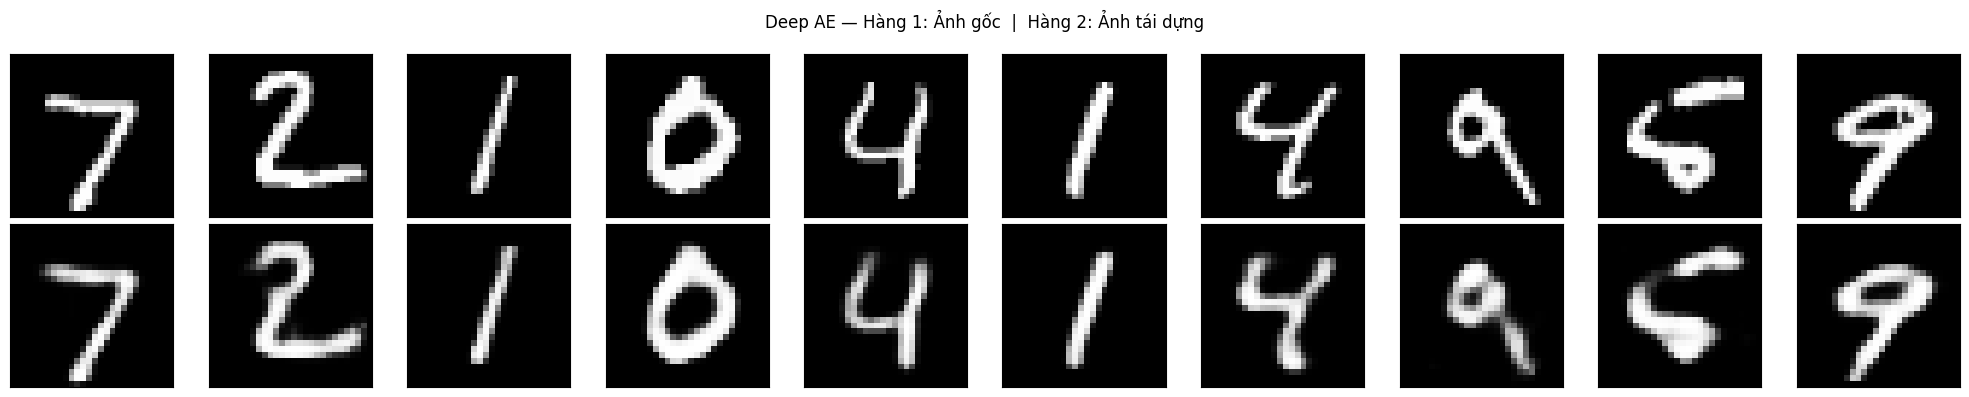

In [13]:
encoded_imgs  = encoder.predict(x_test)
decoded_imgs  = decoder.predict(encoded_imgs)

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.suptitle('Deep AE — Hàng 1: Ảnh gốc  |  Hàng 2: Ảnh tái dựng', fontsize=12)
plt.tight_layout()
plt.show()

#Vẽ đồ thị loss theo epochs

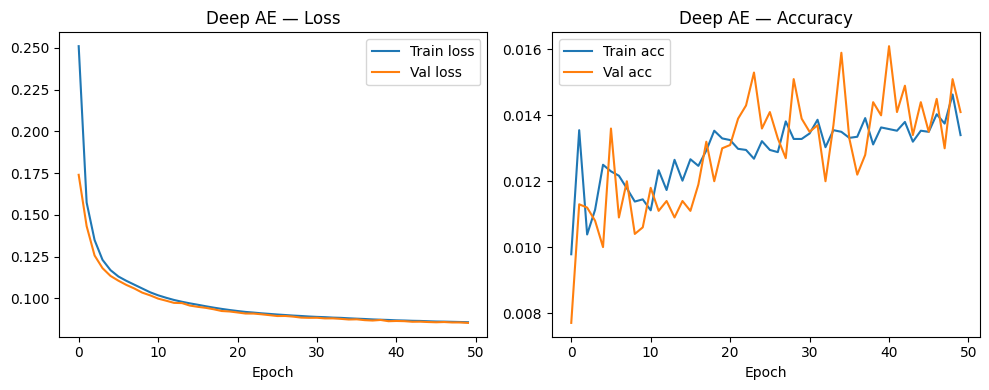

In [14]:
# So sánh train loss vs val loss của Deep AE
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_deep.history['loss'],     label='Train loss')
plt.plot(history_deep.history['val_loss'], label='Val loss')
plt.title('Deep AE — Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_deep.history['accuracy'],     label='Train acc')
plt.plot(history_deep.history['val_accuracy'], label='Val acc')
plt.title('Deep AE — Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

#cài đặt Autoencoder trên CIFAR-10

#1 Nạp thư viện

In [15]:
import numpy as np
import keras
from keras import layers
from keras.datasets import cifar10
import matplotlib.pyplot as plt


#Nạp và chuẩn hóa CIFAR-10

In [16]:
# Nạp dữ liệu — có 10 nhãn: airplane, automobile, bird, cat,
#               deer, dog, frog, horse, ship, truck
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Chuẩn hóa pixel về [0, 1]
x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.

# KHÔNG làm phẳng — giữ nguyên shape (H, W, C) cho Conv2D
print("x_train shape:", x_train.shape)  # (50000, 32, 32, 3)
print("x_test shape :", x_test.shape)   # (10000, 32, 32, 3)

# Tên nhãn để hiển thị sau
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
x_train shape: (50000, 32, 32, 3)
x_test shape : (10000, 32, 32, 3)


#Xây dựng Convolutional Autoencoder

In [17]:
# ── INPUT ────────────────────────────────────────────────
input_img = keras.Input(shape=(32, 32, 3))

# ── ENCODER ─────────────────────────────────────────────
# Conv2D(filters, kernel_size, activation, padding='same')
# padding='same' giữ nguyên H, W → MaxPool mới thu nhỏ
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)  # 32×32 → 16×16
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)  # 16×16 → 8×8
# Bottleneck: shape (8, 8, 64) — nén 32×32×3=3072 xuống 8×8×64=4096

# ── DECODER ─────────────────────────────────────────────
# UpSampling2D tái dựng kích thước (đối xứng với MaxPool)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)                          # 8×8 → 16×16
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)                          # 16×16 → 32×32
# Layer cuối: 3 filter = 3 kênh RGB, sigmoid → pixel ∈ [0,1]
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# ── BUILD MODELS ─────────────────────────────────────────
autoencoder = keras.Model(input_img, decoded)
encoder     = keras.Model(input_img, encoded)

autoencoder.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

# Compile và huấn luyện

In [ ]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

history = autoencoder.fit(
    x_train, x_train,          # input = target (unsupervised)
    epochs=50,
    batch_size=128,            # nhỏ hơn MNIST vì ảnh nặng hơn
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 202s 506ms/step - loss: 0.5735 - val_loss: 0.5624
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 199s 501ms/step - loss: 0.5603 - val_loss: 0.5599
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 210s 537ms/step - loss: 0.5588 - val_loss: 0.5589
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 200s 513ms/step - loss: 0.5579 - val_loss: 0.5608
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 196s 501ms/step - loss: 0.5574 - val_loss: 0.5578
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 197s 504ms/step - loss: 0.5568 - val_loss: 0.5571
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 197s 504ms/step - loss: 0.5563 - val_loss: 0.5569
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 195s 499ms/step - loss: 0.5559 - val_loss: 0.5569
Epoch 9/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 196s 501ms/step - loss: 0.5555 - val_loss: 0.5564
Epoch 10/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 195s 498ms/step - loss: 0.5552 - val_loss: 0.5563
Epoch 11/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 204s 503ms/step - loss: 0.5550 - val_loss: 0.5555
Epoch 12

#Dự báo (encode & decode)

In [ ]:
# Lấy ảnh tái dựng từ autoencoder
decoded_imgs = autoencoder.predict(x_test)

# Lấy vector đặc trưng từ encoder
encoded_imgs = encoder.predict(x_test)

print("Encoded shape:", encoded_imgs.shape)  # (10000, 8, 8, 64)
print("Decoded shape:", decoded_imgs.shape)  # (10000, 32, 32, 3)

#Hiển thị ảnh gốc và ảnh tái dựng

In [ ]:
n = 10
plt.figure(figsize=(20, 5))

for i in range(n):
    label = class_names[y_test[i][0]]

    # Hàng 1: ảnh GỐC
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])          # ảnh màu, không cần gray()
    ax.set_title(label, fontsize=8)
    ax.axis('off')

    # Hàng 2: ảnh TÁI DỰNG
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    ax.set_title('recon', fontsize=8)
    ax.axis('off')

plt.suptitle('CIFAR-10 — Hàng 1: Gốc  |  Hàng 2: Tái dựng', fontsize=12)
plt.tight_layout()
plt.show()

#RNN

#Nạp thư viện

In [19]:
from pandas import read_csv
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

# Hàm định nghĩa mô hình RNN

In [27]:
# Tham số:
#   hidden_units : số neuron trong SimpleRNN (ví dụ: 2, 3, 32...)
#   dense_units  : số neuron output (thường = 1 cho dự báo 1 giá trị)
#   input_shape  : (time_steps, features) — ví dụ (3, 1) hoặc (12, 1)
#   activation   : [activation_RNN, activation_Dense]
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()

    # SimpleRNN: xử lý chuỗi time_steps bước
    model.add(SimpleRNN(
        hidden_units,
        input_shape=input_shape,
        activation=activation[0]
    ))

    # Dense: tầng output cho ra giá trị dự báo
    model.add(Dense(
        dense_units,
        activation=activation[1]
    ))

    model.compile(optimizer='adam', loss='mse') # Changed 'mean_square_error' to 'mse'
    return model

# Demo: 2 hidden units, 1 output, input shape (3 timesteps, 1 feature)
demo_RNN = create_RNN(
    hidden_units=2,
    dense_units=1,
    input_shape=(3, 1),
    activation=['linear', 'linear']
)
demo_RNN.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)



```
#Xem các tham số sinh bởi RNN
```



In [21]:
# Lấy toàn bộ weight của mô hình demo
wx = demo_RNN.get_weights()[0]  # (features × hidden) — kết nối input→hidden
wh = demo_RNN.get_weights()[1]  # (hidden × hidden)   — kết nối hidden→hidden
bh = demo_RNN.get_weights()[2]  # (hidden,)            — bias tầng recurrent
wy = demo_RNN.get_weights()[3]  # (hidden × dense)    — kết nối hidden→output
by = demo_RNN.get_weights()[4]  # (dense,)             — bias tầng output

print('wx=', wx)  # shape (1, 2)
print('wh=', wh)  # shape (2, 2)
print('bh=', bh)  # shape (2,)
print('wy=', wy)  # shape (2, 1)
print('by=', by)  # shape (1,)

wx= [[-0.69432855  1.2038296 ]]
wh= [[-0.74175584 -0.67067003]
 [-0.67067003  0.74175584]]
bh= [0. 0.]
wy= [[0.81388485]
 [0.17325354]]
by= [0.]




```
# Tính vector hidden thủ công và so sánh với model
```



In [22]:
# Input chuỗi x = [1, 2, 3] — 3 time steps, 1 feature
x = np.array([1, 2, 3])

# Reshape sang (samples=1, time_steps=3, features=1)
x_input = np.reshape(x, (1, 3, 1))
y_predict_model = demo_RNN.predict(x_input)

# ── Tính thủ công theo công thức ────────────────────────
# h_{t+1} = f(wx·x_t + wh·h_t + bh)   (activation = linear → f(x)=x)
# y_t     = f(wy·h_t + by)

m = 2                            # số hidden units
h0 = np.zeros(m)                 # hidden state ban đầu = 0

h1 = np.dot(x[0], wx) + bh + h0                  # t=0
h2 = np.dot(x[1], wx) + np.dot(h1, wh) + bh      # t=1
h3 = np.dot(x[2], wx) + np.dot(h2, wh) + bh      # t=2

# Output từ hidden state cuối
o3 = np.dot(h3, wy) + by

print('h1:', h1)
print('h2:', h2)
print('h3:', h3)
print('Prediction of model    :', y_predict_model)
print('Prediction from manual :', o3)
# Hai kết quả phải bằng nhau → chứng minh công thức đúng

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
h1: [[-0.69432855  1.20382965]]
h2: [[-1.6810073   3.76627232]]
h3: [[-3.36201463  7.53254466]]
Prediction of model    : [[-1.4312526]]
Prediction from manual : [[-1.43125278]]


# ÁP DỤNG RNN CHO DỰ BÁO CHUỖI THỜI GIAN

#Đọc và chuẩn hóa dữ liệu Sunspots

In [23]:
# Hàm đọc CSV, chuẩn hóa MinMax, chia train/test
def get_train_test(url, split_percent=0.8):
    # usecols=[1]: chỉ lấy cột Sunspots (bỏ cột Month)
    df   = read_csv(url, usecols=[1], engine='python')
    data = np.array(df.values.astype('float32'))

    # Chuẩn hóa về [0, 1]
    scaler = MinMaxScaler(feature_range=(0, 1))
    data   = scaler.fit_transform(data).flatten()

    n     = len(data)
    split = int(n * split_percent)

    train_data = data[:split]
    test_data  = data[split:]
    return train_data, test_data, data, scaler

sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
train_data, test_data, data, scaler = get_train_test(sunspots_url)

print(f'Tổng số mẫu : {len(data)}')     # 2820
print(f'Train       : {len(train_data)}') # 2256
print(f'Test        : {len(test_data)}')  # 564

Tổng số mẫu : 2820
Train       : 2256
Test        : 564


#Hàm chuẩn bị dữ liệu X, Y cho RNN

In [25]:
# Ý tưởng: dùng time_steps giá trị liên tiếp làm X,
#           giá trị tiếp theo (time_steps+1) làm Y
#
# Ví dụ time_steps=2, dat=[0,10,20,30,40,50]:
#   X[0]=[0,10]  → Y[0]=20
#   X[1]=[20,30] → Y[1]=40
#   X[2]=[40,50] → (bỏ vì không có Y)

def get_XY(dat, time_steps):
    # Tạo chỉ số Y: [time_steps, time_steps+time_steps, ...]
    y_ind = np.arange(time_steps, len(dat), time_steps)
    Y     = dat[y_ind]

    # Tạo X: lấy từng đoạn time_steps phần tử
    row_x = len(Y)
    X     = dat[:time_steps * row_x] # Sửa lỗi ở đây: thay range(...) bằng giá trị số nguyên
    X     = np.reshape(X, (row_x, time_steps, 1))
    return X, Y

# Dùng 12 time_steps = nhìn lại 12 tháng để dự báo tháng tiếp theo
time_steps = 12
trainX, trainY = get_XY(train_data, time_steps)
testX,  testY  = get_XY(test_data,  time_steps)

print(f'trainX shape: {trainX.shape}')  # (188, 12, 1)
print(f'trainY shape: {trainY.shape}')  # (188,)
print(f'testX  shape: {testX.shape}')   # (47, 12, 1)
print(f'testY  shape: {testY.shape}')   # (47,)

trainX shape: (187, 12, 1)
trainY shape: (187,)
testX  shape: (46, 12, 1)
testY  shape: (46,)


#Tạo RNN model và huấn luyện

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0137
Epoch 2/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0086
Epoch 3/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0065
Epoch 4/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0054
Epoch 5/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0050
Epoch 6/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0047
Epoch 7/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0043
Epoch 8/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0043
Epoch 9/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0041
Epoch 10/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0039
Epoch 11/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0040
Epoch 12/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0039
Epoch 13/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0040
Epoch 14/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0039
Epoch 15/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0038


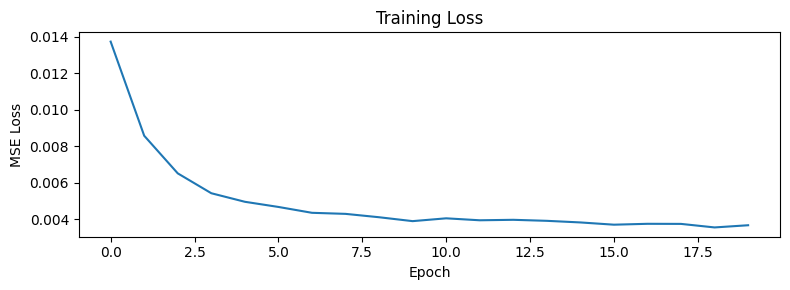

In [28]:
# 3 hidden units, 1 output, input (12 tháng, 1 feature)
# activation tanh: phù hợp với RNN, output ∈ (-1, 1)
model = create_RNN(
    hidden_units=3,
    dense_units=1,
    input_shape=(time_steps, 1),
    activation=['tanh', 'tanh']
)

model_fit = model.fit(
    trainX, trainY,
    epochs=20,
    batch_size=1,   # online learning — cập nhật sau mỗi mẫu
    verbose=1
)

# Vẽ loss để kiểm tra hội tụ
plt.figure(figsize=(8, 3))
plt.plot(model_fit.history['loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.tight_layout()
plt.show()

#Hàm tính và in RMSE

In [29]:
def print_error(trainY, testY, train_predict, test_predict):
    # RMSE = căn bậc hai của MSE
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse  = math.sqrt(mean_squared_error(testY,  test_predict))
    print('Train RMSE: %.3f RMSE' % train_rmse)
    print('Test  RMSE: %.3f RMSE' % test_rmse)

# Dự báo trên tập train và test
train_predict = model.predict(trainX)
test_predict  = model.predict(testX)

print_error(trainY, testY, train_predict, test_predict)
# Kết quả mong đợi: Train RMSE ~0.079, Test RMSE ~0.134

1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Train RMSE: 0.059 RMSE
Test  RMSE: 0.087 RMSE


# Vẽ đồ thị đánh giá kết quả

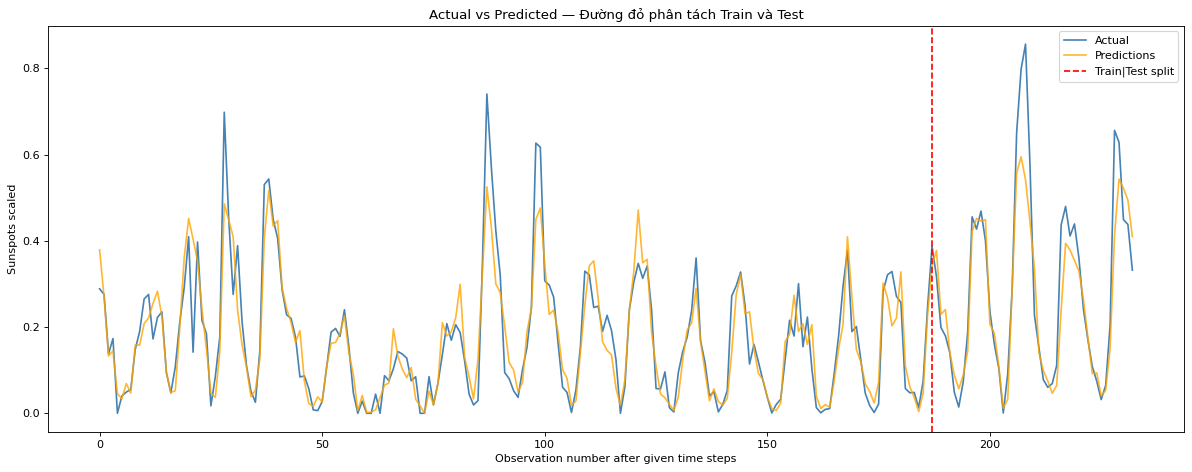

In [30]:
def plot_result(trainY, testY, train_predict, test_predict):
    # Ghép actual và predictions thành mảng liên tục
    actual      = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows        = len(actual)

    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual,      label='Actual',      color='steelblue')
    plt.plot(range(rows), predictions,  label='Predictions', color='orange', alpha=0.8)

    # Đường đỏ phân ranh giữa train và test
    plt.axvline(x=len(trainY), color='r', linewidth=1.5, linestyle='--', label='Train|Test split')

    plt.legend()
    plt.xlabel('Observation number after given time steps')
    plt.ylabel('Sunspots scaled')
    plt.title('Actual vs Predicted — Đường đỏ phân tách Train và Test')
    plt.tight_layout()
    plt.show()

plot_result(trainY, testY, train_predict, test_predict)